In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x : '%.4f' % x)
import sys
sys.path.append('..')
from SRC import sp_limpieza_bank as slb 
from SRC import sp_visualizacion as sv
from SRC import sp_eda as se
from SRC import sp_nulos_num as snn
from SRC import sp_outliers as so
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
df_bank = pd.read_csv('../Data/data_limpios_bank.csv')
df_customer = pd.read_csv('../Data/data_limpios_customer.csv')

In [3]:
df_merged = df_bank.merge(
    df_customer,
    how="left",
    left_on="id_",
    right_on="ID"
)

In [4]:
df_merged.drop(columns=["ID"], inplace=True)

In [5]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job_grouped           42655 non-null  object 
 1   marital               42915 non-null  object 
 2   education             41193 non-null  object 
 3   default               34019 non-null  float64
 4   housing               41974 non-null  float64
 5   loan                  41974 non-null  float64
 6   contact               43000 non-null  object 
 7   duration              43000 non-null  int64  
 8   campaign              43000 non-null  int64  
 9   pdays                 43000 non-null  int64  
 10  previous              43000 non-null  int64  
 11  poutcome              43000 non-null  object 
 12  emp_var_rate          43000 non-null  float64
 13  cons_price_idx        43000 non-null  float64
 14  cons_conf_idx         43000 non-null  float64
 15  nr_employed        

In [6]:
df_merged.head(5)

,job_grouped,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,nr_employed,y,date,latitude,longitude,id_,year,age_iterative,euribor3m_iterative,Income,Kid_Home,Teen_Home,Dt_Customer,Num_Web_Visits_Month,Join_Year
0,manual,married,basic 4y,0.0000,0.0000,0.0000,telephone,261,1,999,0,nonexistent,1.1000,94.0000,-36.4000,5191,no,2019-08-02,41.4950,-71.2330,089b39d8-e4d0-461b-87d4-814d71e0e079,2019,40.2711,4.9000,161770,1,0,2012-04-04,29,2012
1,technical,married,high school,NaN,0.0000,0.0000,telephone,149,1,999,0,nonexistent,1.1000,94.0000,-36.4000,5191,no,2016-09-14,34.6010,-83.9230,e9d37224-cb6f-4942-98d7-46672963d097,2016,57.0000,3.9280,85477,1,1,2012-12-30,7,2012
2,technical,married,high school,0.0000,1.0000,0.0000,telephone,226,1,999,0,nonexistent,1.1000,94.0000,-36.4000,5191,no,2019-02-15,34.9390,-94.8470,3f9f49b5-e410-4948-bf6e-f9244f04918b,2019,37.0000,4.9000,147233,1,1,2012-02-02,5,2012
3,administrative,married,basic 6y,0.0000,0.0000,0.0000,telephone,151,1,999,0,nonexistent,1.1000,94.0000,-36.4000,5191,no,2015-11-29,49.0410,-70.3080,9991fafb-4447-451a-8be2-b0df6098d13e,2015,40.0000,3.6457,121393,1,2,2012-12-21,29,2012
4,technical,married,high school,0.0000,0.0000,1.0000,telephone,307,1,999,0,nonexistent,1.1000,94.0000,-36.4000,5191,no,2017-01-29,38.0330,-104.4630,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2017,56.0000,3.9114,63164,1,2,2012-06-20,20,2012


In [7]:
# Nos aseguramos de que las fechas están en formato datetime

df_merged['Dt_Customer'] = pd.to_datetime(df_merged['Dt_Customer'])
df_merged['date'] = pd.to_datetime(df_merged['date'])

In [8]:
# 1. Tenure en días/años (días/años que el cliente lleva en el banco desde que se unió.)

df_merged['Customer_tenure_days'] = (df_merged['date'] - df_merged['Dt_Customer']).dt.days
df_merged['Customer_tenure_years'] = df_merged['Customer_tenure_days'] / 365

# 2. High_web_visit_flag (1 si el cliente está en el top 25% de visitas al sitio web, 0 si no.)

percentile_75 = df_merged['Num_Web_Visits_Month'].quantile(0.75)
df_merged['High_web_visit_flag'] = (df_merged['Num_Web_Visits_Month'] > percentile_75).astype(int)

# 3. Web_engagement_score (Normalización de NumWebVisitsMonth entre 0 y 1, para comparar la intensidad de visitas.)

df_merged['Web_engagement_score'] = (df_merged['Num_Web_Visits_Month'] - df_merged['Num_Web_Visits_Month'].min()) / \
                                    (df_merged['Num_Web_Visits_Month'].max() - df_merged['Num_Web_Visits_Month'].min())

# 4. Web_visit_intensity (Visitas al mes ajustadas por el tiempo que lleva como cliente.)

df_merged['Web_visit_intensity'] = df_merged['Num_Web_Visits_Month'] / df_merged['Customer_tenure_years'].replace(0, np.nan)

# 5. Tenure_vs_campaign_effort (Número de llamadas de la campaña por año de antigüedad del cliente: campaign / Customer_tenure_years. Mide cuánto esfuerzo de contacto se aplica por antigüedad.)

df_merged['Tenure_vs_campaign_effort'] = df_merged['campaign'] / df_merged['Customer_tenure_years'].replace(0, np.nan)

# 6. Engagement_score_total (Combinación de comportamiento online y de campaña: Web_engagement_score + duration_norm + previous. Se normaliza duration para que sea comparable con el resto.)

df_merged['duration_norm'] = (
    df_merged['duration'] - df_merged['duration'].min()
) / (df_merged['duration'].max() - df_merged['duration'].min())

df_merged['Engagement_score_total'] = (
    df_merged['Web_engagement_score'] +
    df_merged['duration_norm'] +
    df_merged['previous']
)

# 7. Overall_interaction_score (Combinación de engagement online y esfuerzo de campaña.)

df_merged['Overall_interaction_score'] = df_merged['Engagement_score_total'] + df_merged['Tenure_vs_campaign_effort']

# 8. Contact_effort_ratio (Intensidad de contacto según contactos previos.)

df_merged['Contact_effort_ratio'] = df_merged['campaign'] / (df_merged['previous'] + 1)

# 9. Avg_duration_per_contact (Duración promedio por contacto.)

df_merged['Avg_duration_per_contact'] = df_merged['duration'] / df_merged['campaign'].replace(0, np.nan)

# 10. Web_activity_per_contact (Promedio de visitas web por contacto de campaña.)

df_merged['Web_activity_per_contact'] = df_merged['Num_Web_Visits_Month'] / df_merged['campaign'].replace(0, np.nan)





In [9]:
df_merged.columns

Index(['job_grouped', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'nr_employed', 'y',
       'date', 'latitude', 'longitude', 'id_', 'year', 'age_iterative',
       'euribor3m_iterative', 'Income', 'Kid_Home', 'Teen_Home', 'Dt_Customer',
       'Num_Web_Visits_Month', 'Join_Year', 'Customer_tenure_days',
       'Customer_tenure_years', 'High_web_visit_flag', 'Web_engagement_score',
       'Web_visit_intensity', 'Tenure_vs_campaign_effort', 'duration_norm',
       'Engagement_score_total', 'Overall_interaction_score',
       'Contact_effort_ratio', 'Avg_duration_per_contact',
       'Web_activity_per_contact'],
      dtype='object')

In [10]:
df_metricas = df_merged[['Customer_tenure_days', 'Customer_tenure_years', 'High_web_visit_flag', 'Web_engagement_score', 'Web_visit_intensity', 'Tenure_vs_campaign_effort', 'Engagement_score_total', 'Overall_interaction_score', 'Contact_effort_ratio', 'Avg_duration_per_contact', 'Web_activity_per_contact']]

In [11]:
df_metricas.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_tenure_days,42752.0000,1511.7215,629.6012,8.0000,1048.0000,1515.0000,1984.0000,2921.0000
Customer_tenure_years,42752.0000,4.1417,1.7249,0.0219,2.8712,4.1507,5.4356,8.0027
High_web_visit_flag,43000.0000,0.2220,0.4156,0.0000,0.0000,0.0000,0.0000,1.0000
Web_engagement_score,43000.0000,0.5029,0.2980,0.0000,0.2581,0.5161,0.7742,1.0000
Web_visit_intensity,42752.0000,5.6662,9.8144,0.1269,2.0689,4.0047,6.4793,696.8182
Tenure_vs_campaign_effort,42752.0000,0.8332,1.4745,0.1253,0.2704,0.4679,0.8817,91.2500
Engagement_score_total,43000.0000,0.7293,0.5827,0.0012,0.3385,0.6388,0.9374,7.7995
Overall_interaction_score,42752.0000,1.5627,1.6016,0.1366,0.8262,1.2109,1.8153,91.5435
Contact_effort_ratio,43000.0000,2.4237,2.7886,0.1250,1.0000,2.0000,3.0000,56.0000
Avg_duration_per_contact,43000.0000,164.9361,198.3203,0.0000,47.5000,104.0000,207.0000,4918.0000


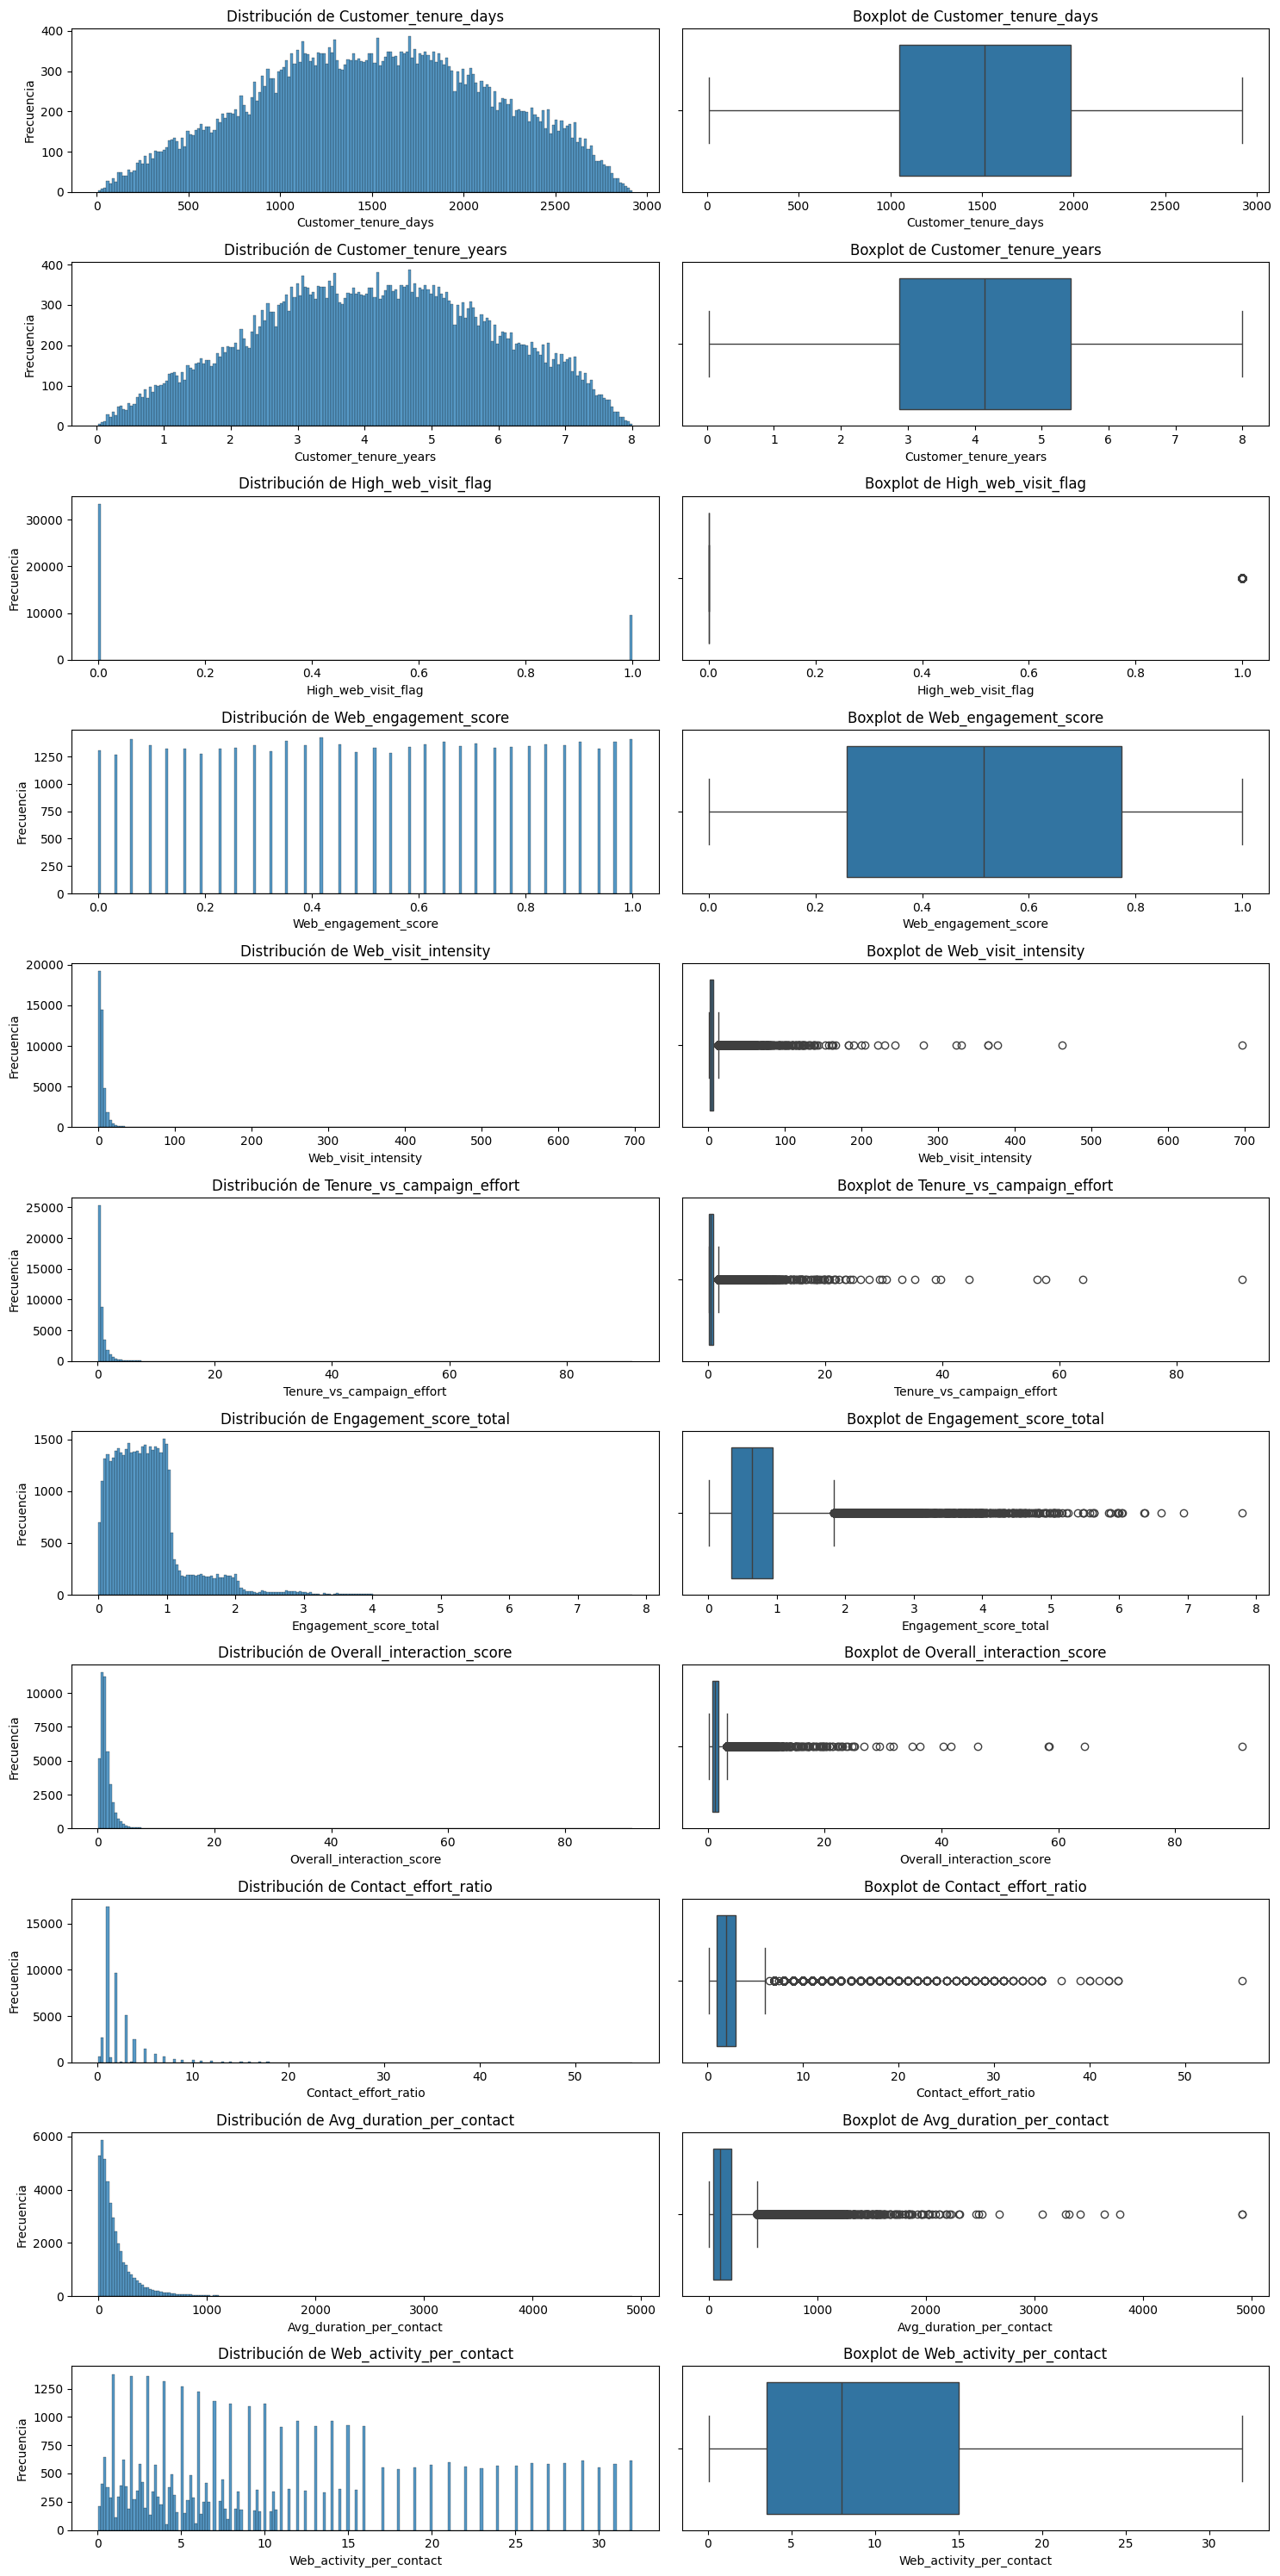

In [12]:
sv.subplot_col_num(df_metricas, df_metricas.columns)

In [13]:
columnas_analizar = ['High_web_visit_flag', 'Web_visit_intensity', 'Tenure_vs_campaign_effort', 'Engagement_score_total', 'Overall_interaction_score', 'Contact_effort_ratio', 'Avg_duration_per_contact']
so.contar_outliers(df_merged, columnas_analizar)

,Column,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount,Outlier%
0,High_web_visit_flag,0.0000,0.0000,0.0000,0.0000,0.0000,9547,22.2000
1,Web_visit_intensity,2.0689,6.4793,4.4104,-4.5466,13.0948,2805,6.5200
2,Tenure_vs_campaign_effort,0.2704,0.8817,0.6114,-0.6467,1.7988,3840,8.9300
3,Engagement_score_total,0.3385,0.9374,0.5989,-0.5600,1.8358,2227,5.1800
4,Overall_interaction_score,0.8262,1.8153,0.9891,-0.6574,3.2989,2852,6.6300
5,Contact_effort_ratio,1.0000,3.0000,2.0000,-2.0000,6.0000,2399,5.5800
6,Avg_duration_per_contact,47.5000,207.0000,159.5000,-191.7500,446.2500,3039,7.0700


({'High_web_visit_flag': 9547,
  'Web_visit_intensity': 2805,
  'Tenure_vs_campaign_effort': 3840,
  'Engagement_score_total': 2227,
  'Overall_interaction_score': 2852,
  'Contact_effort_ratio': 2399,
  'Avg_duration_per_contact': 3039},
 {'High_web_visit_flag': 22.2,
  'Web_visit_intensity': 6.52,
  'Tenure_vs_campaign_effort': 8.93,
  'Engagement_score_total': 5.18,
  'Overall_interaction_score': 6.63,
  'Contact_effort_ratio': 5.58,
  'Avg_duration_per_contact': 7.07})

# 1. Identificación de segmentos de clientes (Clustering)

In [15]:
# Variables para cluster
cluster_vars = [
    'Web_engagement_score',
    'Web_visit_intensity',
    'Tenure_vs_campaign_effort',
    'Avg_duration_per_contact',
    'Overall_interaction_score',
    'Contact_effort_ratio'
]

In [18]:
# Preparamos datos y manejamos Nan
X = df_metricas[cluster_vars].copy()
X = X.fillna(X.median())  # Rellenar NaN con mediana


In [20]:
# Guardar índices para asignar clusters de forma segura
valid_idx = X.index

# Estandarizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
# Clustering con KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Asignar clusters al DataFrame de forma segura con .loc
df_metricas.loc[valid_idx, 'Cluster'] = labels

# Guardar centroides en DataFrame
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_vars)

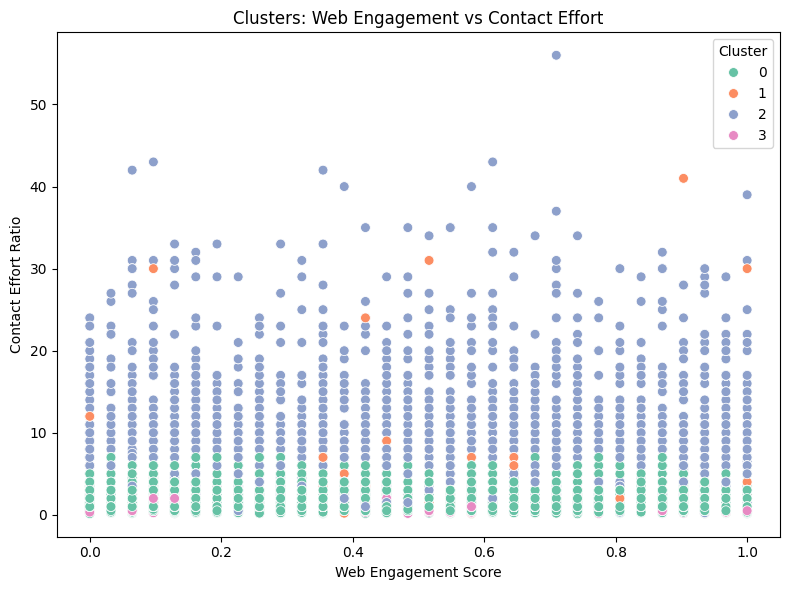

In [22]:
# Scatterplot: Web engagement vs Contact effort

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_metricas,
    x='Web_engagement_score',
    y='Contact_effort_ratio',
    hue='Cluster',
    palette='Set2',
    s=50
)
plt.title('Clusters: Web Engagement vs Contact Effort')
plt.xlabel('Web Engagement Score')
plt.ylabel('Contact Effort Ratio')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2957007925.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_metricas, palette='Set2', hue=None)


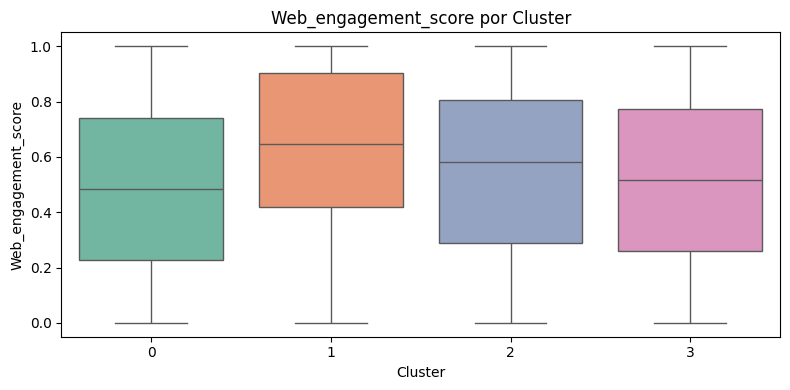

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2957007925.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_metricas, palette='Set2', hue=None)


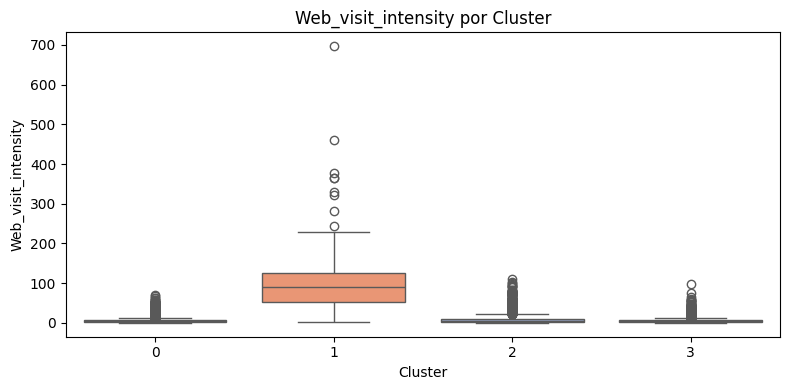

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2957007925.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_metricas, palette='Set2', hue=None)


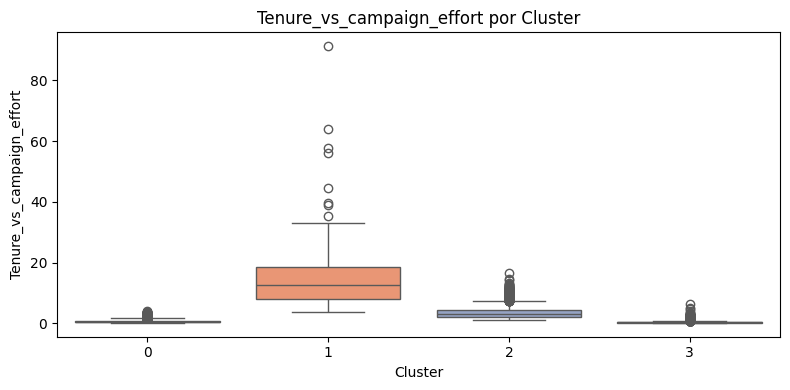

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2957007925.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_metricas, palette='Set2', hue=None)


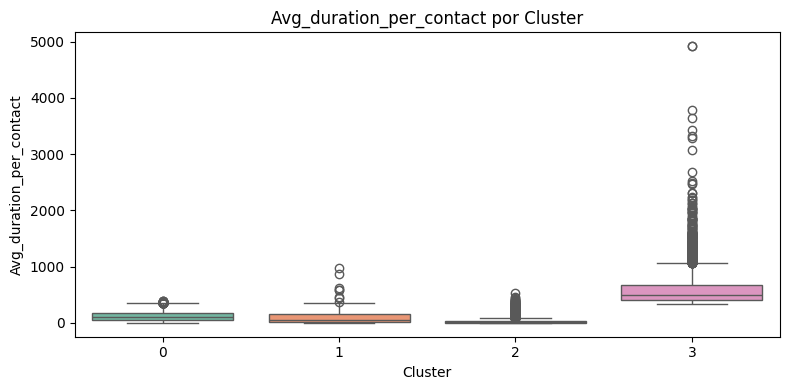

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2957007925.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_metricas, palette='Set2', hue=None)


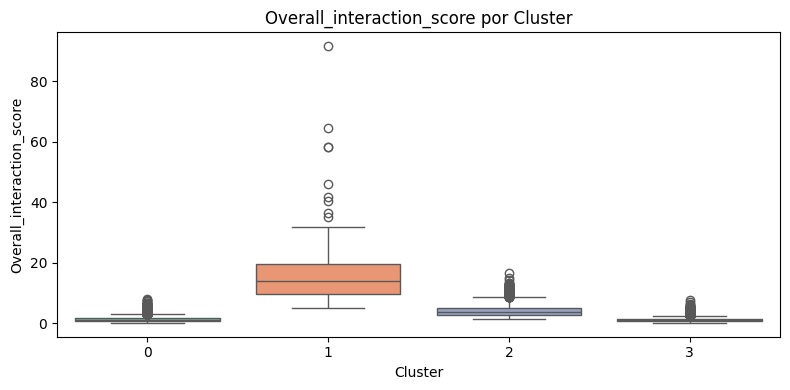

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2957007925.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=df_metricas, palette='Set2', hue=None)


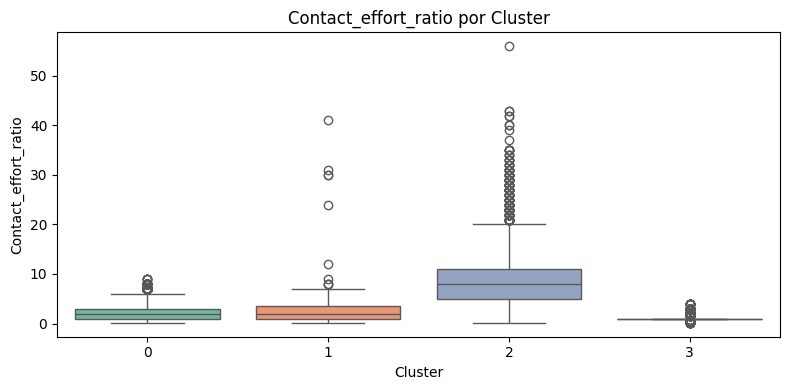

In [24]:
# Boxplots de métricas por cluster

for col in cluster_vars:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='Cluster', y=col, data=df_metricas, palette='Set2', hue=None)
    plt.title(f'{col} por Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

<Figure size 1000x600 with 0 Axes>

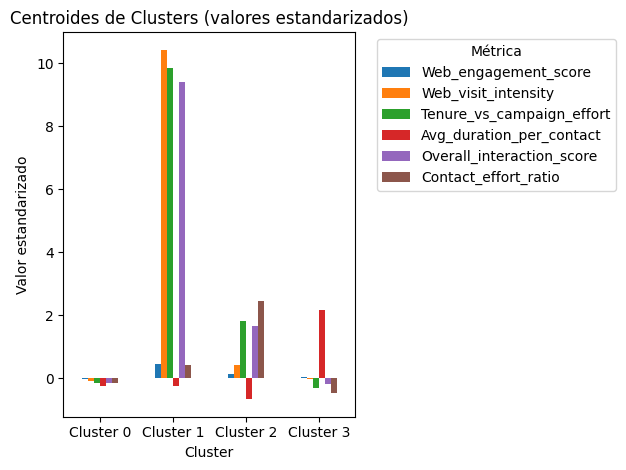

In [25]:
# Visualización de centroides

plt.figure(figsize=(10,6))
centroids.plot(kind='bar')
plt.title('Centroides de Clusters (valores estandarizados)')
plt.xlabel('Cluster')
plt.ylabel('Valor estandarizado')
plt.xticks(ticks=range(len(centroids)), labels=[f'Cluster {i}' for i in range(len(centroids))], rotation=0)
plt.legend(title='Métrica', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# Qué representan los clusters:

- 0 -> Alto engagement web, pocos contactos (clientes activos y fáciles de convertir)
- 1 -> Bajo engagement, alto esfuerzo de contacto (clientes difíciles, "costosos" de abordar)
- 2 -> Engagement medio, contactos moderados (clientes promedio, buena conversión potencial)
- 3 -> Muy alto esfuerzo y alta actividad (clientes "premium" o especiales, requieren atención dedicada)

Centroides de cada cluster (valores estandarizados):


,Web_engagement_score,Web_visit_intensity,Tenure_vs_campaign_effort,Avg_duration_per_contact,Overall_interaction_score,Contact_effort_ratio,Cluster
0,-0.0172,-0.0752,-0.1497,-0.2368,-0.1494,-0.1416,0
1,0.4576,10.4310,9.8616,-0.2465,9.4211,0.4262,1
2,0.1248,0.4324,1.8281,-0.6634,1.6680,2.4521,2
3,0.0373,-0.0105,-0.3009,2.1577,-0.1926,-0.4724,3


Centroides con etiquetas sugeridas:


,Web_engagement_score,Web_visit_intensity,Tenure_vs_campaign_effort,Avg_duration_per_contact,Overall_interaction_score,Contact_effort_ratio,Cluster,Label
0,-0.0172,-0.0752,-0.1497,-0.2368,-0.1494,-0.1416,0,Promedio
1,0.4576,10.4310,9.8616,-0.2465,9.4211,0.4262,1,Premium / Muy activo
2,0.1248,0.4324,1.8281,-0.6634,1.6680,2.4521,2,Premium / Muy activo
3,0.0373,-0.0105,-0.3009,2.1577,-0.1926,-0.4724,3,Promedio


/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2768832783.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_metricas['Cluster_Label'] = df_metricas['Cluster'].map(
/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2768832783.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df_metricas, palette='Set2')


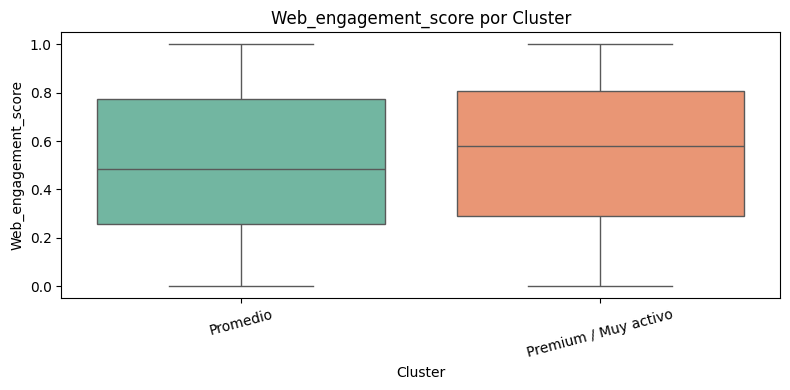

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2768832783.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df_metricas, palette='Set2')


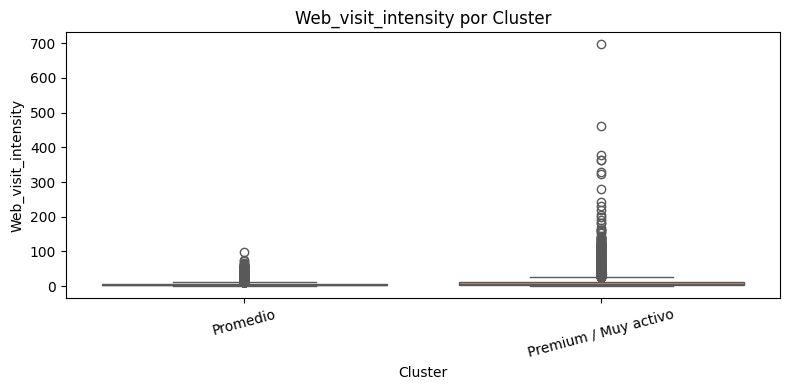

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2768832783.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df_metricas, palette='Set2')


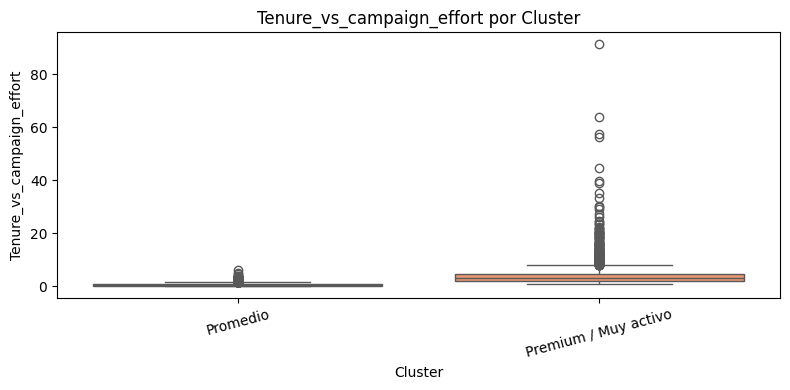

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2768832783.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df_metricas, palette='Set2')


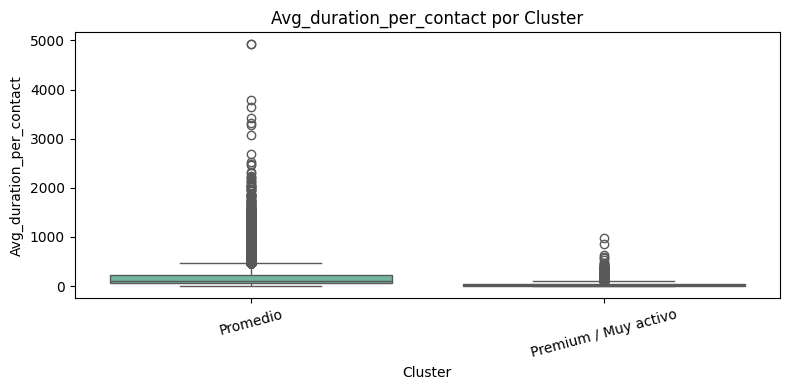

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2768832783.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df_metricas, palette='Set2')


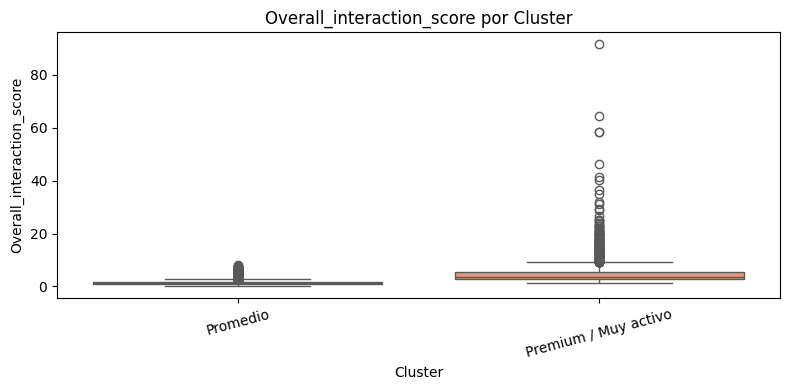

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_20808/2768832783.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df_metricas, palette='Set2')


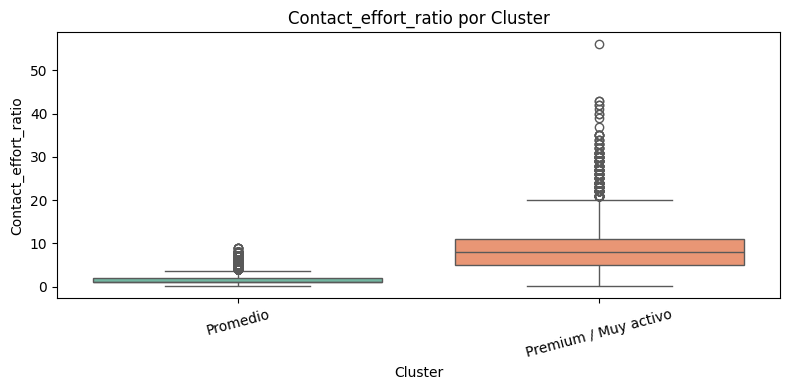

In [26]:
# Crear un DataFrame con centroides y cluster
centroids_df = centroids.copy()
centroids_df['Cluster'] = centroids_df.index

# Mostrar los centroides (valores estandarizados)
print("Centroides de cada cluster (valores estandarizados):")
display(centroids_df)

# Interpretación basada en centroides
cluster_labels = []

for i, row in centroids_df.iterrows():
    # Comparar métricas con valor medio (0 después de estandarización)
    engagement = row['Web_engagement_score']
    effort = row['Contact_effort_ratio']
    
    if engagement > 0.5 and effort < 0:
        label = 'Top Engagement - Fácil'
    elif engagement < 0 and effort > 0.5:
        label = 'Difícil / Alto esfuerzo'
    elif engagement > 0 and effort > 0:
        label = 'Premium / Muy activo'
    else:
        label = 'Promedio'
    
    cluster_labels.append(label)

centroids_df['Label'] = cluster_labels
print("Centroides con etiquetas sugeridas:")
display(centroids_df)

# Asignar etiquetas al DataFrame original
df_metricas['Cluster_Label'] = df_metricas['Cluster'].map(
    centroids_df.set_index('Cluster')['Label']
)

# Boxplots por cluster etiquetado

for col in cluster_vars:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='Cluster_Label', y=col, data=df_metricas, palette='Set2')
    plt.title(f'{col} por Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(col)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

In [28]:
df_merged.to_csv('../Data/data_metricas_datasetsmerged.csv', index = False)